# 05 — Tốc độ & Giá mỗi km · có đáng khai thác thêm cho model giá không?

Gop 2 phan:
1. **Toc do / muc tac duong** (`speed_kmh`, `dur_per_km`) — tuong quan voi gia & he so nhan, kiem
   chung co nen them feature tuong minh khong.
2. **Gia/km** (`price_per_km`) — thu huong phan ra khac: gia = don gia/km x quang duong, kiem chung
   co giam sai so so voi doan thang gia khong.

(Surge da on — notebook nay tap trung tim huong cai thien model **GIA**.)

> ### ⚠️ Phạm vi của notebook này
>
> Notebook này phân tích trên **giá cơ bản** (`base_price` = giá cuối ÷ hệ số nhân) — mục tiêu là
> tìm cách cải thiện **model giá cơ bản**, nên đã **chủ động loại bỏ phần surge**.
>
> **KHÔNG được diễn giải kết quả ở đây thành "giờ/thời tiết không ảnh hưởng giá".** Giờ/thời tiết
> tác động lên giá khách trả **qua kênh hệ số nhân (surge)**, không qua giá cơ bản. Xem
> **`00_TONG_HOP_SO_SANH.ipynb`** để có bức tranh đầy đủ (tách rõ giá cơ bản / hệ số nhân / giá cuối).

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
setup()
df = load(frac=0.15)   # doi frac=1.0 de nap toan bo

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%


**1. Tính cột tốc độ (quãng đường / thời gian)**

`_common.py` đã tính sẵn 2 dạng:
- `speed_kmh` = quote_distance / (quote_duration/3600) → **km/h**, thấp = tắc đường
- `dur_per_km` = (quote_duration/60) / quote_distance → **phút/km**, cao = tắc đường (nghịch đảo tốc độ)

Dùng `dur_per_km` dễ đọc hơn cho việc phân tích tắc đường (không âm, tuyến tính với "mức độ chậm").

In [2]:
print(df[["quote_distance","quote_duration","speed_kmh","dur_per_km"]].describe().round(2))
print(f"\nToc do median: {df.speed_kmh.median():.1f} km/h | Phut/km median: {df.dur_per_km.median():.2f}")

       quote_distance  quote_duration   speed_kmh  dur_per_km
count      1034550.00      1034550.00  1034550.00  1034550.00
mean             6.56         1475.94       17.52        3.86
std              2.19          663.73        6.30        1.39
min              1.11          240.00        2.37        0.49
25%              5.37         1014.69       13.10        2.89
50%              6.17         1368.02       16.50        3.64
75%              8.03         1815.38       20.79        4.58
max             45.00        10800.00      121.34       25.33

Toc do median: 16.5 km/h | Phut/km median: 3.64


**2. Tương quan với GIÁ — có kiểm soát quãng đường**

Nếu không kiểm soát quãng đường, tương quan giữa `dur_per_km` và giá có thể bị nhiễu (chuyến xa
thường vừa đắt vừa lâu). Kiểm soát bằng cách tính tương quan **trong từng dải quãng đường** rồi
lấy trung bình (hàm `control_distance_corr`).

corr(phut/km, gia) KHONG kiem soat = 0.134
corr(phut/km, gia) CO kiem soat quang duong = 0.399
eta(phut/km theo bin, gia) = 0.167  (ty le bien thien gia giai thich boi muc tac)


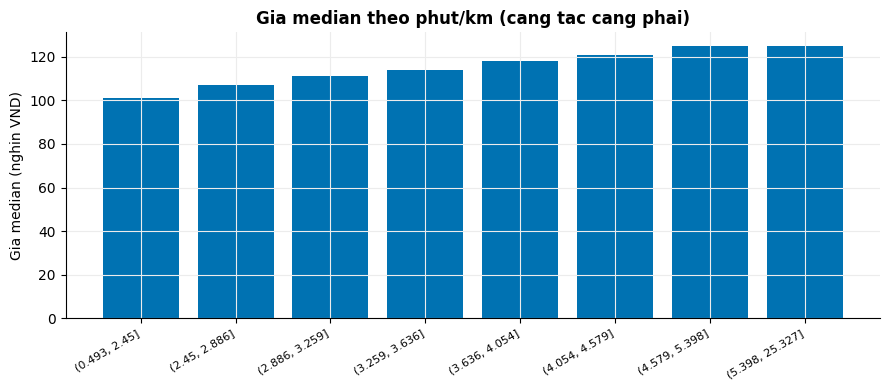

In [3]:
corr_raw = df.dur_per_km.corr(df.price_k)
corr_ctrl = control_distance_corr(df, "dur_per_km", PRICE)
eta_price = eta(binned(df.dur_per_km, 8), df.price_k)
print(f"corr(phut/km, gia) KHONG kiem soat = {corr_raw:.3f}")
print(f"corr(phut/km, gia) CO kiem soat quang duong = {corr_ctrl:.3f}")
print(f"eta(phut/km theo bin, gia) = {eta_price:.3f}  (ty le bien thien gia giai thich boi muc tac)")

fig, ax = plt.subplots(figsize=(9,4))
g = df.groupby(binned(df.dur_per_km, 8)).price_k.median()
ax.bar(range(len(g)), g.values, color=BLUE)
ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30, fontsize=8, ha="right")
ax.set_ylabel("Gia median (nghin VND)"); ax.set_title("Gia median theo phut/km (cang tac cang phai)", fontweight="bold")
plt.tight_layout(); plt.show()

**3. Tương quan với HỆ SỐ NHÂN**

corr(phut/km, he so nhan) = 0.192
eta(phut/km theo bin, he so nhan) = 0.198


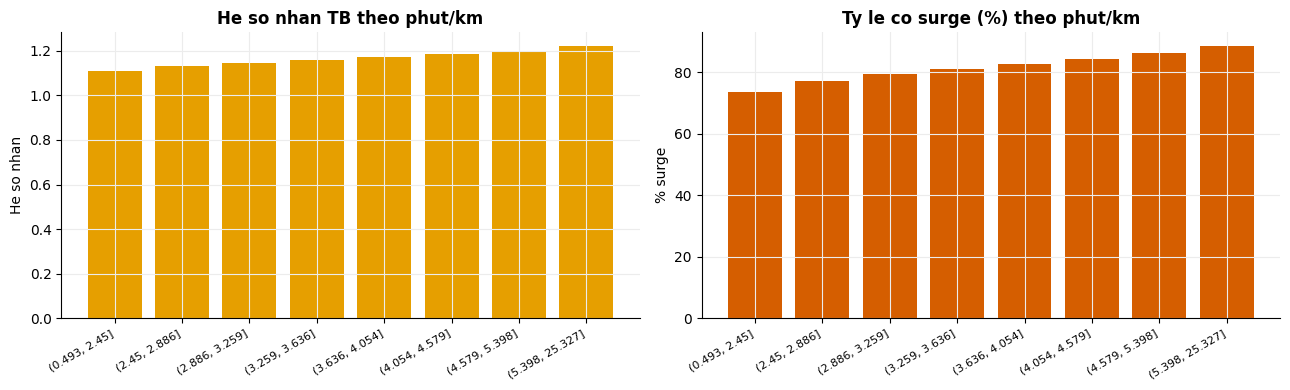

In [4]:
corr_surge = df.dur_per_km.corr(df[SURGE])
eta_surge = eta(binned(df.dur_per_km, 8), df[SURGE])
print(f"corr(phut/km, he so nhan) = {corr_surge:.3f}")
print(f"eta(phut/km theo bin, he so nhan) = {eta_surge:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
g1 = df.groupby(binned(df.dur_per_km, 8))[SURGE].mean()
ax[0].bar(range(len(g1)), g1.values, color=ORANGE)
ax[0].set_xticks(range(len(g1))); ax[0].set_xticklabels(g1.index, rotation=30, fontsize=8, ha="right")
ax[0].set_title("He so nhan TB theo phut/km", fontweight="bold"); ax[0].set_ylabel("He so nhan")

g2 = df.groupby(binned(df.dur_per_km, 8)).is_surge.mean()*100
ax[1].bar(range(len(g2)), g2.values, color=RED)
ax[1].set_xticks(range(len(g2))); ax[1].set_xticklabels(g2.index, rotation=30, fontsize=8, ha="right")
ax[1].set_title("Ty le co surge (%) theo phut/km", fontweight="bold"); ax[1].set_ylabel("% surge")
plt.tight_layout(); plt.show()

**4. Kiểm chứng — thêm `dur_per_km` làm feature riêng có giúp model chính xác hơn không?**

Cây quyết định (HistGB) *có thể* tự học tương tác `quote_distance × quote_duration` mà không cần
feature tường minh. Test thực nghiệm: train 2 model HistGB — (A) chỉ `quote_distance` +
`quote_duration` riêng, (B) thêm cả `dur_per_km` tường minh — so R²/MAE trên cùng tập test.

In [5]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_base = df[["quote_distance","quote_duration"]].copy()
X_plus = df[["quote_distance","quote_duration","dur_per_km"]].copy()
y = np.log(df[PRICE])

Xb_tr, Xb_te, Xp_tr, Xp_te, y_tr, y_te = train_test_split(X_base, X_plus, y, test_size=0.2, random_state=42)

mA = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, random_state=42).fit(Xb_tr, y_tr)
mB = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, random_state=42).fit(Xp_tr, y_tr)

pA = np.exp(mA.predict(Xb_te)); pB = np.exp(mB.predict(Xp_te))
yt = np.exp(y_te)

print("(A) Chi quote_distance + quote_duration:")
print(f"    R2={r2_score(yt,pA):.4f}  MAE={mean_absolute_error(yt,pA):,.0f} VND")
print("(B) Them ca dur_per_km tuong minh:")
print(f"    R2={r2_score(yt,pB):.4f}  MAE={mean_absolute_error(yt,pB):,.0f} VND")
print(f"\nChenh lech MAE (B - A) = {mean_absolute_error(yt,pB)-mean_absolute_error(yt,pA):+,.0f} VND")
print("-> Neu gan 0: cay da tu hoc duoc tuong tac nay, khong can them feature.")
print("-> Neu B tot ro ret hon: dang de them dur_per_km/speed_kmh vao bo feature chinh thuc.")

(A) Chi quote_distance + quote_duration:
    R2=0.5813  MAE=22,341 VND
(B) Them ca dur_per_km tuong minh:
    R2=0.5825  MAE=22,322 VND

Chenh lech MAE (B - A) = -19 VND
-> Neu gan 0: cay da tu hoc duoc tuong tac nay, khong can them feature.
-> Neu B tot ro ret hon: dang de them dur_per_km/speed_kmh vao bo feature chinh thuc.


**Kết luận**

- Bước 2-3 cho thấy mức độ tương quan **thực sự** (đã kiểm soát quãng đường) giữa tắc đường và
  giá/hệ số nhân — nếu eta/corr đủ lớn, tắc đường là tín hiệu thật, không phải nhiễu.
- Bước 4 là câu trả lời trực tiếp: nếu model (A) và (B) gần như bằng nhau → **không cần** thêm
  `dur_per_km` vào `_common_train.py`, vì HistGB/LightGBM/XGBoost (đều là cây) đã tự học tương tác
  `quote_distance × quote_duration` qua nhiều lần chia nhánh, không cần tính sẵn tỷ lệ.
  Ngược lại nếu (B) thắng rõ, nên thêm `dur_per_km` vào `D_NUM`/`B_NUM` trong `_common_train.py`.

---

## Phan 2 -- Gia/km

In [6]:
df["price_per_km"] = df[PRICE] / df.quote_distance.clip(lower=0.1)
print(f"Gia/km  median: {df.price_per_km.median():,.0f} VND/km | std: {df.price_per_km.std():,.0f}")
print(f"He so bien thien (CV) gia goc     : {(df[PRICE].std()/df[PRICE].mean()):.3f}")
print(f"He so bien thien (CV) gia/km      : {(df.price_per_km.std()/df.price_per_km.mean()):.3f}")
print("-> CV thap hon = gia/km ON DINH hon gia goc -> co the de doan hon.")

Gia/km  median: 18,300 VND/km | std: 6,256
He so bien thien (CV) gia goc     : 0.380
He so bien thien (CV) gia/km      : 0.323
-> CV thap hon = gia/km ON DINH hon gia goc -> co the de doan hon.


**1. Giá/km có giảm dần theo quãng đường không? (kinh tế theo quy mô)**

Taxi/ride-hailing thường có cấu trúc: **phí mở cửa cố định + phí/km** → chuyến càng dài, phí mở cửa
càng "loãng" ra, nên đơn giá/km càng **giảm dần**. Kiểm tra xem HCM có đúng mô hình này không.

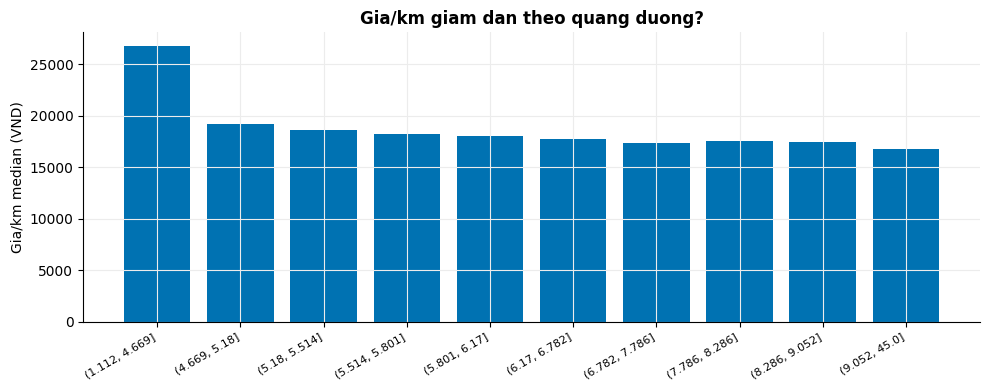

corr(quang duong, gia/km) = -0.401


In [7]:
g = df.groupby(binned(df.quote_distance, 10)).price_per_km.median()
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(range(len(g)), g.values, color=BLUE)
ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30, fontsize=8, ha="right")
ax.set_ylabel("Gia/km median (VND)"); ax.set_title("Gia/km giam dan theo quang duong?", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"corr(quang duong, gia/km) = {df.quote_distance.corr(df.price_per_km):.3f}")

**2. Giá/km có tăng khi tắc đường không? (tốc độ / dur_per_km)**

Nếu cước tính thêm theo phút di chuyển, chuyến tắc (tốc độ thấp) sẽ có đơn giá/km cao hơn cho cùng
quãng đường — đã thấy ở `05_kmpertime.ipynb` với giá tổng, giờ xem cụ thể trên đơn giá/km.

corr(toc do km/h, gia/km) = -0.444  (am = toc do thap -> gia/km cao, dung ky vong)
corr(phut/km, gia/km)     = 0.530


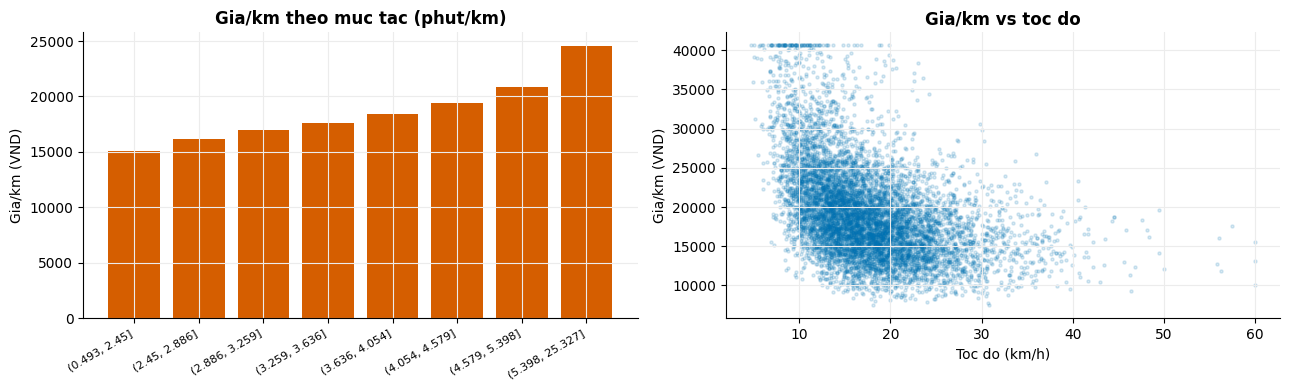

In [8]:
corr_speed = df.speed_kmh.corr(df.price_per_km)
corr_durkm = df.dur_per_km.corr(df.price_per_km)
print(f"corr(toc do km/h, gia/km) = {corr_speed:.3f}  (am = toc do thap -> gia/km cao, dung ky vong)")
print(f"corr(phut/km, gia/km)     = {corr_durkm:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
g1 = df.groupby(binned(df.dur_per_km, 8)).price_per_km.median()
ax[0].bar(range(len(g1)), g1.values, color=RED)
ax[0].set_xticks(range(len(g1))); ax[0].set_xticklabels(g1.index, rotation=30, fontsize=8, ha="right")
ax[0].set_title("Gia/km theo muc tac (phut/km)", fontweight="bold"); ax[0].set_ylabel("Gia/km (VND)")

s = df.sample(min(8000,len(df)), random_state=0)
ax[1].scatter(s.speed_kmh.clip(0,60), s.price_per_km.clip(0, s.price_per_km.quantile(.99)), s=5, alpha=.15, color=BLUE)
ax[1].set_xlabel("Toc do (km/h)"); ax[1].set_ylabel("Gia/km (VND)"); ax[1].set_title("Gia/km vs toc do", fontweight="bold")
plt.tight_layout(); plt.show()

**3. Giá/tốc độ (`price_per_km` chuẩn hóa theo dịch vụ + giờ)**

Xem đơn giá/km trung bình theo **loại xe** và **giờ trong ngày** — để biết biến động đơn giá có
theo pattern rõ ràng (dịch vụ, giờ cao điểm) hay ngẫu nhiên.

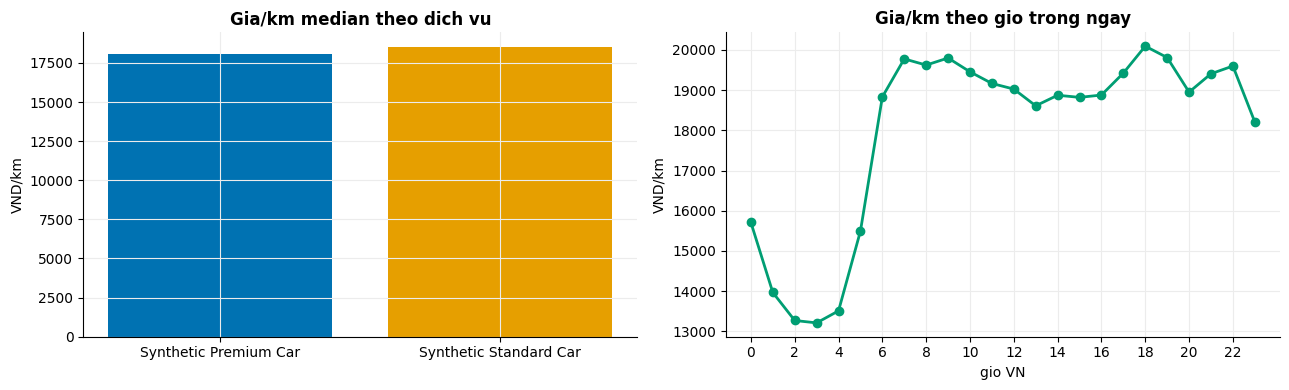

eta(dich vu, gia/km) = 0.011


eta(gio, gia/km)     = 0.338


In [9]:
g_service = df.groupby("service_name").price_per_km.median()
g_hour = df.groupby("gio_vn").price_per_km.median()
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].bar(g_service.index, g_service.values, color=[BLUE,ORANGE])
ax[0].set_title("Gia/km median theo dich vu", fontweight="bold"); ax[0].set_ylabel("VND/km")
ax[1].plot(g_hour.index, g_hour.values, marker="o", color=GREEN, lw=2)
ax[1].set_xticks(range(0,24,2)); ax[1].set_xlabel("gio VN"); ax[1].set_ylabel("VND/km")
ax[1].set_title("Gia/km theo gio trong ngay", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"eta(dich vu, gia/km) = {eta(df.service_name, df.price_per_km):.3f}")
print(f"eta(gio, gia/km)     = {eta(df.gio_vn, df.price_per_km):.3f}")

**4. Kiểm chứng — dự đoán GIÁ/KM rồi × quãng đường có tốt hơn dự đoán GIÁ thẳng không?**

So 2 cách trên cùng feature (distance, duration, service, giờ, lịch sử giá, giá quan sát gần nhất):
- **(A) Dự đoán thẳng** `target_shown_price` (log)
- **(C) Dự đoán `price_per_km`** (log), rồi nhân lại với `quote_distance` để ra giá cuối

Đánh giá cả 2 trên **cùng thước đo cuối cùng: giá VND thực tế** (không so sánh R² của price_per_km
với R² của giá — 2 target khác thang đo, so trực tiếp sẽ sai lệch).

In [10]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder

CAT = ["service_name","pickup_location_name","dropoff_location_name"]
NUM = ["quote_distance","quote_duration","gio_vn","latest_observed_price",
       "history_60m_price_mean","history_60m_price_std"]
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X = df[NUM].copy()
X[CAT] = enc.fit_transform(df[CAT].astype(str))
X = X[CAT+NUM]

idx_tr, idx_te = train_test_split(df.index, test_size=0.2, random_state=42)
Xtr, Xte = X.loc[idx_tr], X.loc[idx_te]
dist_te = df.loc[idx_te, "quote_distance"].clip(lower=0.1)
price_te = df.loc[idx_te, PRICE]

def tao():
    return HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, categorical_features=CAT, random_state=42)

# (A) Du doan thang gia
mA = tao().fit(Xtr, np.log(df.loc[idx_tr, PRICE]))
predA = np.exp(mA.predict(Xte))

# (C) Du doan gia/km roi nhan lai quang duong
mC = tao().fit(Xtr, np.log(df.loc[idx_tr, "price_per_km"]))
predC_perkm = np.exp(mC.predict(Xte))
predC = predC_perkm * dist_te

print("(A) Du doan thang GIA:")
print(f"    R2={r2_score(price_te,predA):.4f}  MAE={mean_absolute_error(price_te,predA):,.0f} VND  MAPE={np.mean(np.abs((price_te-predA)/price_te))*100:.1f}%")
print("(C) Du doan GIA/KM roi nhan lai quang duong:")
print(f"    R2={r2_score(price_te,predC):.4f}  MAE={mean_absolute_error(price_te,predC):,.0f} VND  MAPE={np.mean(np.abs((price_te-predC)/price_te))*100:.1f}%")
print(f"\nChenh lech MAE (C - A) = {mean_absolute_error(price_te,predC)-mean_absolute_error(price_te,predA):+,.0f} VND")
print("-> Am (C tot hon): dang chuyen model sang huong nay.")
print("-> Duong/gan 0: khong co loi, giu nguyen cach du doan thang gia.")

(A) Du doan thang GIA:
    R2=0.7035  MAE=18,569 VND  MAPE=15.5%
(C) Du doan GIA/KM roi nhan lai quang duong:
    R2=0.7048  MAE=18,546 VND  MAPE=15.5%

Chenh lech MAE (C - A) = -22 VND
-> Am (C tot hon): dang chuyen model sang huong nay.
-> Duong/gan 0: khong co loi, giu nguyen cach du doan thang gia.


**Kết luận**

- Bước 1-3: nếu `price_per_km` biến động **ít hơn** giá gốc (CV thấp hơn — xem bước 0) và có pattern
  rõ theo quãng đường/tắc đường/dịch vụ/giờ → đây là tín hiệu tốt cho việc đổi hướng target.
- Bước 4 là câu trả lời thực nghiệm trực tiếp: so MAE/MAPE trên **cùng đơn vị VND cuối cùng** giữa
  2 cách. Nếu (C) thắng rõ → nên đổi `train_hybrid.ipynb`/`train_gia.ipynb` sang học `price_per_km`
  thay vì `target_shown_price`/`base_price` trực tiếp — cùng ý tưởng phân rã như Hybrid (base×surge)
  nhưng ở một trục khác (giá = đơn giá/km × quãng đường).